# Experiment 02: Chunking Strategy Comparison

## Objective

The objective of this experiment is to compare two commonly used chunking strategies in Retrieval-Augmented Generation (RAG) systems:

- Recursive Character Text Splitter
- Token Text Splitter

The comparison focuses on:

- Number of chunks generated
- Average chunk size
- Average token count
- Execution time
- Suitability for production RAG systems

## Import Required Libraries

In [1]:
import fitz
import tiktoken

from recursive_chunking import recursive_chunking
from token_chunking import token_chunking

## Extract Text from PDF

In [2]:
def extract_text(pdf_path):

    document = fitz.open(pdf_path)

    text = ""

    for page in document:
        text += page.get_text()

    document.close()

    return text


pdf_path = "SBP-Act.pdf"

text = extract_text(pdf_path)

print(f"Characters: {len(text)}")


Characters: 105293


## Recursive Character Chunking

In [3]:
recursive = recursive_chunking(text)

recursive

{'method': 'Recursive Character Chunking',
 'chunks': ['STATE BANK OF PAKISTAN  \n(Incorporated under the State Bank of Pakistan Act, 1956)  \n \n \n \n \n                                                                      THE STATE BANK OF PAKISTAN  \nAct, 1956  \n(As amended upto 28-01-2022)  \n \n \n \n \n \n \n \n \n \n \n \n \n \n \nBLANK PAGE  \n \n \n                 \n \n \n \n \n \n \n \n \n \n \n \nTHE STATE BANK OF PAKISTAN  \n \nACT, 1956  \nCONTENTS  \nCHAPTER I - PRELIMINARY  \nSECTIONS \nPage \n1. \nShort title, extent and commencement \n1 \n2. \nDefinitions',
  '1 \n2. \nDefinitions \n2 \nCHAPTER II - ESTABLISHMENT, \nINCORPORATION AND SHARE CAPITAL \nOF THE BANK \n3. \nEstablishment and incorporation of the Bank \n5 \n4. \nShare Capital                                                                                               5 \n4A. Re-capitalization                                                                                         6 \n4B.     Objectives    

## Token Chunking

In [4]:
token = token_chunking(text)

token

{'method': 'Token Chunking',
 'chunks': ['         \n \n \n \n \n \n \nSTATE BANK OF PAKISTAN  \n(Incorporated under the State Bank of Pakistan Act, 1956)  \n \n \n \n \n                                                                      THE STATE BANK OF PAKISTAN  \nAct, 1956  \n(As amended upto 28-01-2022)  \n \n \n \n \n \n \n \n \n \n \n \n \n \n \nBLANK PAGE  \n \n \n                 \n \n \n \n \n \n \n \n \n \n \n \nTHE STATE BANK OF PAKISTAN  \n \nACT, 1956  \nCONTENTS  \nCHAPTER I - PRELIMINARY  \nSECTIONS \nPage \n1. \nShort title, extent and commencement \n1 \n2. \nDefinitions \n2 \nCHAPTER II - ESTABLISHMENT, \nINCORPORATION AND SHARE CAPITAL \nOF THE BANK \n3. \nEstablishment and incorporation of the Bank \n5 \n4. \nShare Capital                                                                                               5 \n4A. Re-capitalization                                     ',
  '    5 \n4A. Re-capitalization                                                      

## Compare Results

In [5]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Number of Chunks",
        "Average Characters",
        "Average Tokens",
        "Execution Time (sec)"
    ],

    "Recursive":[
        recursive["num_chunks"],
        recursive["avg_characters"],
        recursive["avg_tokens"],
        recursive["time"]
    ],

    "Token":[
        token["num_chunks"],
        token["avg_characters"],
        token["avg_tokens"],
        token["time"]
    ]

})

comparison

,Metric,Recursive,Token
0,Number of Chunks,232.0000,75.0000
1,Average Characters,457.7800,1557.1200
2,Average Tokens,107.9400,362.1900
3,Execution Time (sec),0.0024,0.2007


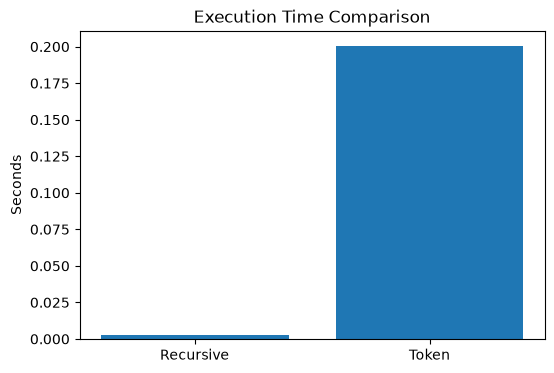

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Recursive","Token"],
    [recursive["time"], token["time"]]
)

plt.title("Execution Time Comparison")

plt.ylabel("Seconds")

plt.show()

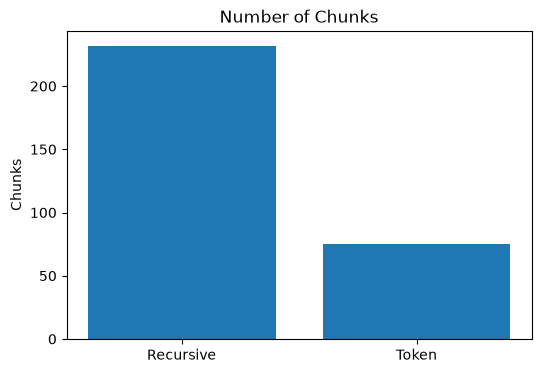

In [8]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Recursive","Token"],
    [recursive["num_chunks"], token["num_chunks"]]
)

plt.title("Number of Chunks")

plt.ylabel("Chunks")

plt.show()

# Conclusion

## Recursive Character Chunking

Advantages

- Very fast
- Produces smaller chunks
- Easy to configure
- Most widely used in production LangChain applications

Disadvantages

- Character-based instead of token-aware

---

## Token Chunking

Advantages

- Respects tokenizer boundaries
- Better for strict LLM context limits

Disadvantages

- Slower
- Produces larger chunks
- Requires tokenizer

---

## Final Recommendation

Recursive Character Text Splitter is recommended for this project because it provides significantly faster execution while producing manageable chunks suitable for retrieval in a production RAG pipeline.

Token Chunking is useful when strict token limits must be maintained for a specific LLM.